# Driver Feedback Analysis

## Sentiment Analysis using RoBERTa

The sentiment analysis notebook includes:

1. Load processed feedback dataset
2. Explore sentiment distribution
3. Encode target labels
4. Split dataset
5. Tokenize feedback
6. Fine-tune RoBERTa
7. Evaluate model performance
8. Save trained model and encoder
9. Perform inference

## Import libraries

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn

from datasets import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)

from utils.config import (
    TRANSFORMER_DIR,
    ENCODER_DIR,
)

from utils.data_loader import load_processed_feedback

from utils.encoding import (
    encode_labels,
    save_encoder,
)

from utils.visualization import (
    plot_sentiment_distribution,
    plot_confusion_matrix,
)

from utils.model_utils import (
    save_transformer_model,
    compute_class_weights,
    WeightedTrainer,
)

## Load Dataset

In [3]:
df = load_processed_feedback()

df.head()

,trip_id,timestamp,rating,feedback_text,sentiment,clean_text,character_count,word_count,average_word_length
0,TR000001,2025-12-26 12:44:39,1.0,I completed running New York Marathon requeste...,neutral,I completed running New York Marathon requeste...,2259,359,5.295265
1,TR000002,2025-12-28 03:07:09,1.0,My appointment time auto repairs required earl...,neutral,My appointment time auto repairs required earl...,1147,169,5.792899
2,TR000003,2025-04-02 22:33:06,1.0,Whether I using Uber ride service Uber Eats or...,negative,Whether I using Uber ride service Uber Eats or...,661,99,5.686869
3,TR000004,2025-12-02 18:42:33,1.0,Why hard understand I trying retrieve Uber cab...,negative,Why hard understand I trying retrieve Uber cab...,445,74,5.027027
4,TR000005,2025-03-05 02:37:34,1.0,I South Beach FL I staying major hotel ordered...,positive,I South Beach FL I staying major hotel ordered...,304,55,4.545455


## Inspect Dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   trip_id              1344 non-null   str    
 1   timestamp            1344 non-null   str    
 2   rating               1344 non-null   float64
 3   feedback_text        1344 non-null   str    
 4   sentiment            1344 non-null   str    
 5   clean_text           1344 non-null   str    
 6   character_count      1344 non-null   int64  
 7   word_count           1344 non-null   int64  
 8   average_word_length  1344 non-null   float64
dtypes: float64(2), int64(2), str(5)
memory usage: 1.2 MB


In [5]:
df.describe(include="all")

,trip_id,timestamp,rating,feedback_text,sentiment,clean_text,character_count,word_count,average_word_length
count,1344,1344,1344.000000,1344,1344,1344,1344.000000,1344.000000,1344.000000
unique,1344,1344,NaN,1342,3,1342,NaN,NaN,NaN
top,TR000001,2025-12-26 12:44:39,NaN,I use Uber occasions car needed repair I used ...,negative,I use Uber occasions car needed repair I used ...,NaN,NaN,NaN
freq,1,1,NaN,2,555,2,NaN,NaN,NaN
mean,NaN,NaN,1.627232,NaN,NaN,NaN,432.390625,70.798363,5.123091
std,NaN,NaN,1.296149,NaN,NaN,NaN,425.129594,68.511405,0.529118
min,NaN,NaN,1.000000,NaN,NaN,NaN,6.000000,2.000000,2.500000
25%,NaN,NaN,1.000000,NaN,NaN,NaN,171.750000,28.000000,4.785714
50%,NaN,NaN,1.000000,NaN,NaN,NaN,307.500000,51.000000,5.086957
75%,NaN,NaN,1.000000,NaN,NaN,NaN,554.250000,92.000000,5.420263


In [6]:
df.shape

(1344, 9)

## Exploratory Data Analysis

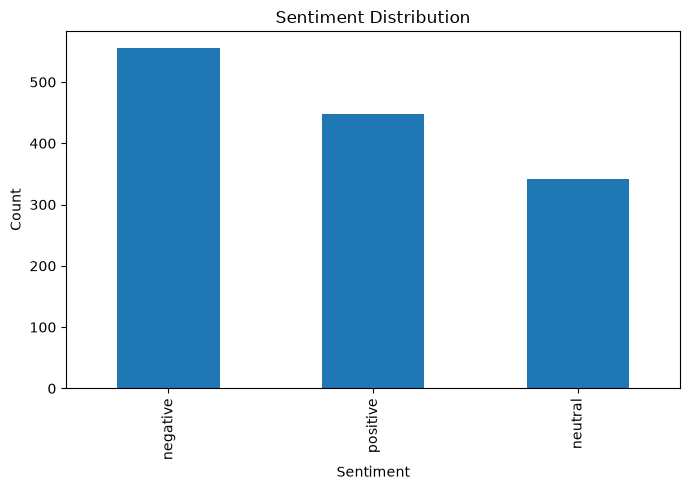

In [7]:
fig = plot_sentiment_distribution(df)

plt.show()

### Missing Values

In [8]:
df.isna().sum()

trip_id                0
timestamp              0
rating                 0
feedback_text          0
sentiment              0
clean_text             0
character_count        0
word_count             0
average_word_length    0
dtype: int64

### Duplicate Records

In [9]:
duplicates = df.duplicated().sum()

print(f"Duplicate records: {duplicates}")

Duplicate records: 0


In [10]:
if duplicates:
    df = df.drop_duplicates()

## Label Encoding

In [11]:
df, encoder = encode_labels(df, "sentiment",)

save_encoder(
    encoder,
    ENCODER_DIR / "sentiment_label_encoder.pkl",
)

## Split Dataset

In [12]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42,
)

print(f"Training Set   : {len(train_df)}")
print(f"Validation Set : {len(val_df)}")
print(f"Testing Set    : {len(test_df)}")

Training Set   : 940
Validation Set : 202
Testing Set    : 202


In [ ]:
class_weights = compute_class_weights(
    train_df["label"]
)

print(class_weights)

## Convert to Hugging Face Dataset

In [13]:
train_ds = Dataset.from_pandas(
    train_df[["clean_text", "label"]].reset_index(drop=True)
)

val_ds = Dataset.from_pandas(
    val_df[["clean_text", "label"]].reset_index(drop=True)
)

test_ds = Dataset.from_pandas(
    test_df[["clean_text", "label"]].reset_index(drop=True)
)

## Tokenization

In [14]:
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["clean_text"],
        truncation=True,
        max_length=128,
    )

config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/20.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

In [15]:
train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

Map:   0%|          | 0/940 [00:00<?, ? examples/s]

Map:   0%|          | 0/202 [00:00<?, ? examples/s]

Map:   0%|          | 0/202 [00:00<?, ? examples/s]

In [16]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

## Initialize Model

In [17]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(encoder.classes_),
    id2label=dict(enumerate(encoder.classes_)),
    label2id={
        label: index
        for index, label in enumerate(encoder.classes_)
    },
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  599MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Compute Evaluation Metrics

In [18]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1,
    )

    return {
        "accuracy": accuracy_score(
            labels,
            predictions,
        ),
        "f1_macro": f1_score(
            labels,
            predictions,
            average="macro",
        )
    }

## Training Configuration

In [19]:
training_args = TrainingArguments(
    output_dir="./checkpoints",

    learning_rate=2e-5,

    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,

    num_train_epochs=3,

    weight_decay=0.01,
    warmup_steps=0.1,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",

    logging_steps=100,

    save_total_limit=1,

    dataloader_num_workers=2,
    dataloader_pin_memory=False,

    report_to="none",
)

## Initialize Trainer

In [20]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ],
)

## Train Model

In [ ]:
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


## Evaluate Model

In [ ]:
validation_results = trainer.evaluate()

validation_results

In [ ]:
test_results = trainer.predict(test_ds)

y_true = test_results.label_ids

y_pred = np.argmax(
    test_results.predictions,
    axis=-1,
)

## Classification Report

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=encoder.classes_,
    )
)

## Confusion Matrix

In [ ]:
cm = confusion_matrix(y_true, y_pred)

fig = plot_confusion_matrix(
    cm,
    encoder.classes_,
)

plt.show()

## Save Model

In [ ]:
save_transformer_model(
    trainer,
    tokenizer,
    TRANSFORMER_DIR / "sentiment_model",
)

## Save Label Encoder

In [ ]:
save_encoder(
    encoder,
    ENCODER_DIR / "sentiment_label_encoder.pkl",
)

## Sample Prediction

In [ ]:
from transformers import pipeline

model_path = TRANSFORMER_DIR / "sentiment_model"

sentiment_pipeline = pipeline(
    "text-classification",
    model=str(model_path),
    tokenizer=str(model_path),
)

sample_feedback = [
    {
        "Feedback": "The driver arrived early, was polite, and the ride was smooth.",
        "Expected Label": "Positive"
    },
    {
        "Feedback": "The trip was okay. Nothing special happened during the ride.",
        "Expected Label": "Neutral"
    },
    {
        "Feedback": "The driver was rude and kept speeding throughout the trip.",
        "Expected Label": "Negative"
    },
    {
        "Feedback": "Although the driver was friendly, the vehicle was not very clean.",
        "Expected Label": "Neutral"
    },
    {
        "Feedback": "The driver got lost, but apologized and eventually reached the destination safely.",
        "Expected Label": "Neutral"
    },
    {
        "Feedback": "Excellent service! The driver helped me carry my luggage and drove carefully.",
        "Expected Label": "Positive"
    },
    {
        "Feedback": "The driver was constantly using the phone while driving.",
        "Expected Label": "Negative"
    },
    {
        "Feedback": "Traffic was heavy, but the driver remained patient and professional.",
        "Expected Label": "Positive"
    },
    {
        "Feedback": "I had to wait a long time before the driver arrived.",
        "Expected Label": "Negative"
    },
    {
        "Feedback": "Overall, the experience was satisfactory and I would ride again.",
        "Expected Label": "Positive"
    }
]

# Generate predictions
predictions = sentiment_pipeline(
    [sample["Feedback"] for sample in sample_feedback]
)

# Create results table
results = []

for sample, prediction in zip(sample_feedback, predictions):
    results.append({
        "Feedback": sample["Feedback"],
        "Expected Label": sample["Expected Label"],
        "Predicted Label": prediction["label"],
        "Confidence": f"{prediction['score']:.4f}"
    })

results_df = pd.DataFrame(results)

results_df